# 03 — Imputation Strategies

**Input:** `output/labs_raw.parquet` — 4-hourly time-series, 54 551 ICU stays × 6 bins × 20 labs + binary `was_measured_*` indicators  
**Output:** 7 imputed patient-level feature matrices, each saved as a Parquet file in `output/`

| # | Key | Strategy |
|---|---|---|
| A | `native_nan` | No imputation — NaN + missingness indicators (LightGBM NaN-routing) |
| B | `median` | Global median per feature (MCAR strawman) |
| C | `ffill_recency` | Forward fill + per-lab recency weight feature (0.9^h) |
| D | `knn` | KNN (k=5) on flattened patient matrix |
| E | `mice` | MICE / IterativeImputer with LightGBM estimator |
| F | `ffill_decay` | Forward fill + data-driven per-analyte decay toward empirical mean |
| G | `clinical_default` | Forward fill + population-normal reference values for unordered labs |

**Two-stage design** (see Section 3):  
- Strategies A, B, C, F, G operate on the **4h time-series** then flatten  
- Strategies D, E operate **cross-sectionally** on the already-flattened Strategy-A matrix

All strategies carry binary `was_measured_<lab>` indicators (MNAR mitigation: Singh et al. 2021; Sharafoddini et al. 2019).  
Strategy A is the only one with remaining NaN — intentional: LightGBM routes NaN to gain-optimal child nodes, provably Bayes-optimal under MNAR (Le Morvan et al. 2021).

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import KNNImputer, IterativeImputer
import lightgbm as lgb

SEED      = 42
BIN_HOURS = 4   # each bin_4h step = 4 hours
N_BINS    = 6   # bins 0-5 covering first 24h of ICU stay
OUTPUT    = Path("output")
OUTPUT.mkdir(exist_ok=True)

np.random.seed(SEED)
sns.set_style("whitegrid")
print(f"pandas {pd.__version__}, numpy {np.__version__}, lgb {lgb.__version__}")

pandas 3.0.0, numpy 2.4.2, lgb 4.6.0


## 2. Load Data

In [2]:
labs    = pd.read_parquet(OUTPUT / "labs_raw.parquet")
vitals  = pd.read_parquet(OUTPUT / "vitals_raw.parquet")
cohort  = pd.read_parquet(OUTPUT / "cohort.parquet")

# Merge labs + vitals on (stay_id, bin_4h)
# Both share the same 6-bin structure; left join keeps all lab rows
labs = labs.merge(vitals, on=["stay_id", "bin_4h"], how="left")

# Column groups — auto-detected after merge
_NON_FEAT = {"subject_id", "stay_id", "bin_4h"}
ALL_VALUE_COLS = [
    c for c in labs.columns
    if c not in _NON_FEAT and not c.startswith("was_measured_")
]
IND_COLS = [c for c in labs.columns if c.startswith("was_measured_")]

# Keep backward-compatible alias used throughout this notebook
LAB_COLS = ALL_VALUE_COLS

print(f"labs+vitals : {labs.shape}  "
      f"({labs['stay_id'].nunique():,} stays × {N_BINS} bins × {len(ALL_VALUE_COLS)} features)")
print(f"cohort      : {cohort.shape}  (mortality {cohort['hospital_expire_flag'].mean():.1%})")
print(f"\nALL_VALUE_COLS ({len(ALL_VALUE_COLS)}): {sorted(ALL_VALUE_COLS)}")
print(f"\nOverall missing rates:")
miss = (labs[ALL_VALUE_COLS].isnull().mean() * 100).sort_values(ascending=False)
for col, pct in miss.items():
    print(f"  {col:<22} {pct:5.1f}%")

labs+vitals : (327306, 73)  (54,551 stays × 6 bins × 35 features)
cohort      : (54551, 11)  (mortality 10.8%)

ALL_VALUE_COLS (35): ['BUN', 'Base Excess', 'Bicarbonate', 'Bilirubin', 'Calcium', 'Chloride', 'Creatinine', 'Glucose', 'Hematocrit', 'Hemoglobin', 'INR', 'Lactate', 'Magnesium', 'PTT', 'PaCO2', 'PaO2', 'Platelets', 'Sodium', 'WBC', 'abp_dia', 'abp_mean', 'abp_sys', 'fio2', 'gcs_eye', 'gcs_motor', 'gcs_verbal', 'heart_rate', 'nibp_dia', 'nibp_mean', 'nibp_sys', 'pH', 'peep', 'resp_rate', 'spo2', 'temp_c']

Overall missing rates:
  Hemoglobin              95.1%
  Bilirubin               90.9%
  Glucose                 89.2%
  Lactate                 80.4%
  INR                     79.0%
  PTT                     78.3%
  PaCO2                   76.3%
  Base Excess             76.3%
  PaO2                    76.2%
  Calcium                 75.3%
  pH                      74.4%
  Magnesium               73.4%
  WBC                     71.9%
  Platelets               71.4%
  peep 

## 3. Missingness Overview

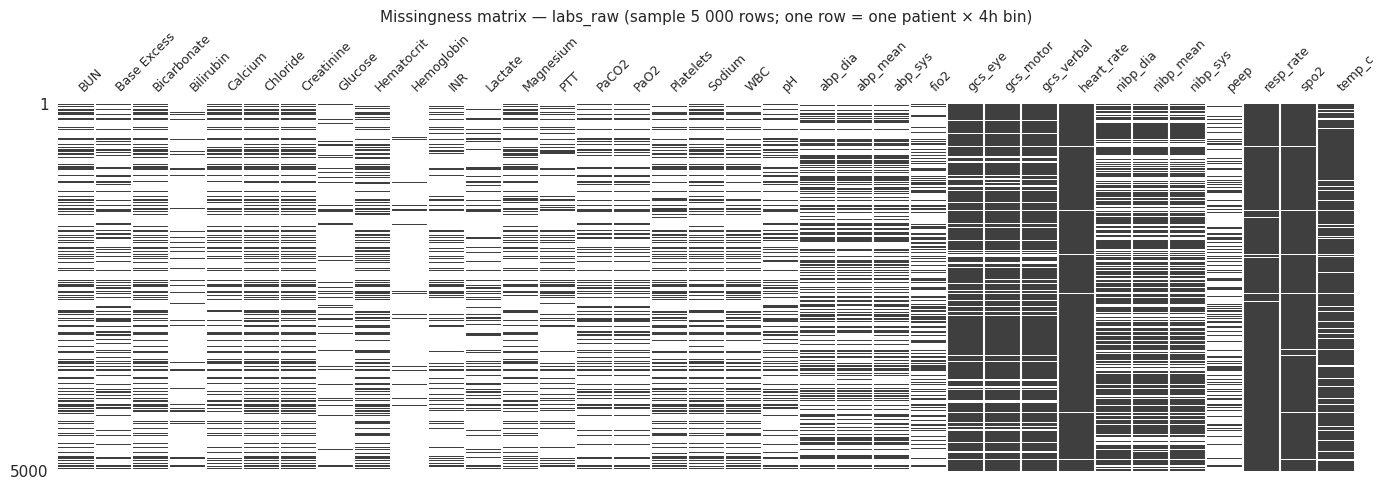

Saved: output/fig_missingness_before_imputation.png


In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
msno.matrix(
    labs[LAB_COLS].sample(5_000, random_state=SEED),
    ax=ax, sparkline=False, fontsize=9
)
ax.set_title(
    "Missingness matrix — labs_raw (sample 5 000 rows; one row = one patient × 4h bin)",
    fontsize=11
)
plt.tight_layout()
plt.savefig(OUTPUT / "fig_missingness_before_imputation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/fig_missingness_before_imputation.png")

## 4. Design: Two-Stage Architecture

ICU labs are measured 1–3 times per 24h window, so each 4h bin is **structurally empty** for most labs — not clinically missing. Applying cross-sectional methods (KNN, MICE) directly to the sparse 6×20 time-grid would impute "not-scheduled" slots, conflating clinical absence with missingness.

We therefore split the strategies into two stages:

**Stage 1 — Temporal strategies** (operate on the 4h time-series, then flatten):  
These use each patient's own trajectory to carry values forward or anchor to a reference.  
→ Strategies A (none), B (median), C (ffill + recency), F (ffill + learned decay), G (clinical default)

**Stage 2 — Cross-sectional strategies** (operate on the already-flattened patient matrix):  
These borrow from similar patients across the cohort, appropriate at the patient level where missingness reflects genuine clinical decisions.  
→ Strategies D (KNN), E (MICE)

**Flatten schema:** for each lab → `{lab}_mean`, `{lab}_min`, `{lab}_max`, `{lab}_last` (last non-NaN in 24h). Plus `was_measured_{lab}` (max per stay = 1 if ever ordered). Demographics added last.

All 7 flat matrices include binary `was_measured_*` indicators — these encode the MNAR mechanism and are the primary mitigation for informative missingness (Sharafoddini et al. 2019; Singh et al. 2021).

## 5. Helper: Flatten Time-Series → Patient Matrix

In [4]:
def flatten_stays(
    ts_df: pd.DataFrame,
    lab_cols: list,
    ind_cols: list,
    extra_cols: list | None = None,
) -> pd.DataFrame:
    """
    Aggregate 4-hourly time-series (6 bins per stay) to one row per patient.

    For each lab    : mean, min, max, last (last non-NaN = most recent measurement)
    For each indicator: max (= 1 if lab ever measured in 24h window)
    For extra_cols  : last value in the window (e.g. recency features)

    All aggregates return NaN when no measurement exists in the 24h window.
    """
    ts = ts_df.sort_values(["stay_id", "bin_4h"])
    grp = ts.groupby("stay_id", sort=False)

    parts = {}
    for lab in lab_cols:
        s = grp[lab]
        parts[f"{lab}_mean"] = s.mean()
        parts[f"{lab}_min"]  = s.min()
        parts[f"{lab}_max"]  = s.max()
        parts[f"{lab}_last"] = s.last()   # last non-NaN = most recent measurement

    for ind in ind_cols:
        parts[ind] = grp[ind].max()        # 1 if ever measured in 24h window

    if extra_cols:
        for col in extra_cols:
            parts[col] = grp[col].last()   # last bin value

    return pd.DataFrame(parts).reset_index()


# Feature group references used across all strategies
LAB_FEAT_COLS = (
    [f"{l}_mean" for l in LAB_COLS]
    + [f"{l}_min"  for l in LAB_COLS]
    + [f"{l}_max"  for l in LAB_COLS]
    + [f"{l}_last" for l in LAB_COLS]
)
print(f"Flat lab feature columns: {len(LAB_FEAT_COLS)}  ({len(LAB_COLS)} labs × 4 aggregates)")
print(f"Missingness indicators  : {len(IND_COLS)}")
print(f"Total features (before demographics): {len(LAB_FEAT_COLS) + len(IND_COLS)}")

Flat lab feature columns: 140  (35 labs × 4 aggregates)
Missingness indicators  : 35
Total features (before demographics): 175


---
## 6. Strategy A — No Imputation (native NaN + indicators)

**Clinical rationale:** Under MNAR, the *pattern* of missingness is itself informative — sicker patients get *more* measurements (Sharafoddini et al. 2019). Imputing can destroy this signal. LightGBM natively routes NaN values to the gain-optimal child node at each split, which is provably Bayes-optimal even under MNAR (Le Morvan et al. 2021).  
This is the true baseline: **"can any imputation strategy beat doing nothing?"**

The `was_measured_*` columns (already in `labs_raw`) encode the missingness structure for models that cannot natively handle NaN.

In [5]:
print("Strategy A: No imputation (native NaN + missingness indicators)")

flat_A = flatten_stays(labs, LAB_COLS, IND_COLS)

n_nan = flat_A[LAB_FEAT_COLS].isnull().sum().sum()
n_total = flat_A.shape[0] * len(LAB_FEAT_COLS)
print(f"Shape   : {flat_A.shape}")
print(f"NaN     : {n_nan:,} / {n_total:,} cells ({n_nan/n_total:.1%}) — intentional, LightGBM handles NaN natively")
print(f"\nNaN per aggregate type:")
for agg in ("mean", "min", "max", "last"):
    cols = [f"{l}_{agg}" for l in LAB_COLS]
    n = flat_A[cols].isnull().sum().sum()
    print(f"  {agg:<6} {n:>8,} NaN  ({n / (flat_A.shape[0]*len(LAB_COLS)):.1%} of cells)")

Strategy A: No imputation (native NaN + missingness indicators)
Shape   : (54551, 176)
NaN     : 2,174,528 / 7,637,140 cells (28.5%) — intentional, LightGBM handles NaN natively

NaN per aggregate type:
  mean    543,632 NaN  (28.5% of cells)
  min     543,632 NaN  (28.5% of cells)
  max     543,632 NaN  (28.5% of cells)
  last    543,632 NaN  (28.5% of cells)


---
## 7. Strategy B — Global Median

**Clinical rationale:** The naive single-value strawman. Assumes MCAR — empirically false for ICU data.  
Median is preferred over mean because ICU lab distributions are heavily right-skewed (lactate, bilirubin, creatinine, INR): mean is pulled toward extreme values and overestimates the typical patient.  
Median is the standard simple baseline in clinical ML benchmarking (Nijman et al. 2022).  
Under MNAR, both produce biased estimates — this strategy is included to demonstrate AUROC degradation versus Strategy A.

In [6]:
print("Strategy B: Global median imputation")

flat_B = flat_A.copy()

# Compute median on the flattened matrix (preserves right-skew protection)
medians_flat = flat_B[LAB_FEAT_COLS].median()
flat_B[LAB_FEAT_COLS] = flat_B[LAB_FEAT_COLS].fillna(medians_flat)

n_nan = flat_B[LAB_FEAT_COLS].isnull().sum().sum()
print(f"Shape : {flat_B.shape}")
print(f"NaN   : {n_nan}  (should be 0)")
assert n_nan == 0, "Residual NaN after median fill"

Strategy B: Global median imputation
Shape : (54551, 176)
NaN   : 0  (should be 0)


---
## 8. Helper: Recency Feature (used by Strategies C and F)

For each lab at each 4h bin, we compute a **staleness weight**:

$$\text{recency}_{t} = 0.9^{\Delta h}$$

where $\Delta h$ = hours since the last measurement of that lab in this patient's stay.  
- At the measurement bin: $\Delta h = 0 \Rightarrow \text{recency} = 1.0$ (completely fresh)  
- 4h later: $0.9^4 = 0.66$; 8h: $0.9^8 = 0.43$; 12h: $0.9^{12} = 0.28$  
- If the lab was never measured before this bin: recency = 0.0 (complete staleness)  

When flattened, we take the recency at the **last bin** (bin_4h = 5, i.e. hours 20–24) — this tells the downstream model how stale the most recent available lab value is at the end of the observation window.  
The model can learn to weight stale forward-filled values differently per analyte via LightGBM feature importance.

In [7]:
def add_recency_features(
    ts_df: pd.DataFrame,
    lab_cols: list,
    decay_per_hour: float = 0.9,
    bin_hours: int = BIN_HOURS,
) -> pd.DataFrame:
    """
    Add recency_<lab> feature per bin = decay_per_hour ^ hours_since_last_measurement.

    Computed from the *original* (un-imputed) missingness pattern, so it correctly
    reflects how stale the forward-filled value is at each time step.
    """
    ts = ts_df.sort_values(["stay_id", "bin_4h"]).copy()

    for lab in lab_cols:
        # bin_4h of last measurement (forward-filled within each stay)
        ts["_meas_bin"] = ts["bin_4h"].where(ts[lab].notna())
        ts["_lmb"] = ts.groupby("stay_id")["_meas_bin"].transform("ffill")

        hours_since = (ts["bin_4h"] - ts["_lmb"]) * bin_hours

        # NaN hours_since means no measurement has occurred yet in this stay
        ts[f"recency_{lab}"] = np.where(
            hours_since.isna(),
            0.0,                              # never measured before → full staleness
            decay_per_hour ** hours_since,    # 1.0 at measurement bin, decays after
        )

    ts = ts.drop(columns=["_meas_bin", "_lmb"])
    return ts


RECENCY_COLS = [f"recency_{lab}" for lab in LAB_COLS]
print(f"Recency columns: {len(RECENCY_COLS)}  (one per lab, computed before ffill)")

Recency columns: 35  (one per lab, computed before ffill)


---
## 9. Strategy C — Forward Fill + Recency Feature

**Clinical rationale:** The most recent measurement is the clinician's best current estimate. Forward-filling (LOCF) propagates it until the next measurement or the end of the window.  
Naive LOCF inflates Type I error up to 0.164 in statistical tests (Lachin 2016). We mitigate this by adding a per-lab recency weight feature (0.9^hours) that tells the model *how stale* the carried-forward value is — the model can then discount stale values automatically via learned feature weights.  
Bins before the first measurement (no prior value to carry) are filled with the global median.

**Forward fill order:** sort by `[stay_id, bin_4h]` → `groupby(stay_id).ffill()` → residual median fill.

In [8]:
print("Strategy C: Forward fill + recency feature (0.9^hours since last measurement)")

# Step 1: compute recency on original (un-imputed) data
ts_C = add_recency_features(labs, LAB_COLS)   # already sorted by [stay_id, bin_4h]

# Step 2: forward fill lab values within each stay
ts_C[LAB_COLS] = ts_C.groupby("stay_id")[LAB_COLS].transform("ffill")

# Step 3: fill residual NaN (bins before first measurement) with global median
medians_ts = labs[LAB_COLS].median()
ts_C[LAB_COLS] = ts_C[LAB_COLS].fillna(medians_ts)

# Step 4: flatten — lab aggregates + indicators + recency at last bin
flat_C = flatten_stays(ts_C, LAB_COLS, IND_COLS, extra_cols=RECENCY_COLS)

n_nan = flat_C[LAB_FEAT_COLS].isnull().sum().sum()
print(f"Shape   : {flat_C.shape}")
print(f"NaN in lab features: {n_nan}  (should be 0)")
assert n_nan == 0
print(f"\nRecency at end of 24h window (bin 5) — mean per lab:")
rec_means = flat_C[RECENCY_COLS].mean().sort_values()
for lab, val in rec_means.items():
    name = lab.replace("recency_", "")
    print(f"  {name:<18} {val:.3f}  ({'rarely measured' if val < 0.4 else 'moderately' if val < 0.7 else 'frequently measured'})")

Strategy C: Forward fill + recency feature (0.9^hours since last measurement)
Shape   : (54551, 211)
NaN in lab features: 0  (should be 0)

Recency at end of 24h window (bin 5) — mean per lab:
  Hemoglobin         0.054  (rarely measured)
  Glucose            0.117  (rarely measured)
  Bilirubin          0.141  (rarely measured)
  Lactate            0.227  (rarely measured)
  PaCO2              0.262  (rarely measured)
  Base Excess        0.262  (rarely measured)
  PaO2               0.262  (rarely measured)
  pH                 0.291  (rarely measured)
  peep               0.297  (rarely measured)
  INR                0.304  (rarely measured)
  PTT                0.313  (rarely measured)
  fio2               0.374  (rarely measured)
  abp_mean           0.395  (rarely measured)
  Calcium            0.399  (rarely measured)
  abp_sys            0.420  (moderately)
  abp_dia            0.420  (moderately)
  WBC                0.423  (moderately)
  Platelets          0.426  (moderately)

---
## 10. Strategy F — Forward Fill + Learned Decay

**Clinical rationale:** The longer since a lab was measured, the less reliable the last reading — physiology changes over time. Rather than a fixed staleness rate, we learn a per-analyte decay rate $\gamma$ directly from MIMIC-IV re-measurement intervals.

**Formula:** after an unmeasured gap of $\Delta t$ hours:
$$x_{\text{imputed}} = \gamma^{\Delta t} \cdot x_{\text{last}} + (1 - \gamma^{\Delta t}) \cdot \bar{x}$$

**Learning $\gamma$:** For each analyte, we compute all consecutive measurement gaps per patient, take the median gap, then solve:
$$\gamma^{\text{median gap}} = 0.5 \quad\Rightarrow\quad \gamma = 0.5^{\,1/\text{median gap}}$$
Interpretation: after one median re-measurement interval, the imputed value is halfway between the last reading and the population mean.

**Novel contribution:** No published table of per-analyte ICU carry-forward decay rates exists. Prior work either uses uniform 48h windows (Meyerson et al. 2022; Komorowski et al. 2018) or learns decay rates inside neural networks without extracting them (Che et al. 2018 — GRU-D). Our derived $\gamma$ table is a novel empirical result from MIMIC-IV.

In [9]:
def learn_decay_rates(
    ts_df: pd.DataFrame,
    lab_cols: list,
    bin_hours: int = BIN_HOURS,
    target_residual: float = 0.5,
) -> pd.DataFrame:
    """
    Derive per-analyte exponential decay rate gamma from MIMIC-IV re-measurement intervals.

    gamma^(median_gap_h) = target_residual  =>  gamma = target_residual^(1/median_gap_h)

    Interpretation: after one median re-measurement gap, the carried value has decayed
    (1 - target_residual) of the way toward the empirical population mean.
    """
    ts = ts_df.sort_values(["stay_id", "bin_4h"])
    records = []

    for lab in lab_cols:
        # Consecutive measurement gaps within each stay
        meas = ts.loc[ts[lab].notna(), ["stay_id", "bin_4h"]].copy()
        meas["prev_bin"] = meas.groupby("stay_id")["bin_4h"].shift(1)
        meas["gap_h"]    = (meas["bin_4h"] - meas["prev_bin"]) * bin_hours
        gaps = meas["gap_h"].dropna()

        if len(gaps) >= 10 and gaps.median() > 0:
            med_gap  = gaps.median()
            mean_gap = gaps.mean()
            p25, p75 = gaps.quantile(0.25), gaps.quantile(0.75)
            gamma = float(target_residual ** (1.0 / med_gap))
        else:
            med_gap = mean_gap = p25 = p75 = np.nan
            gamma = 0.9  # fallback: hourly decay

        records.append({
            "analyte":       lab,
            "n_gaps":        len(gaps),
            "median_gap_h":  round(med_gap,  1) if not np.isnan(med_gap)  else np.nan,
            "mean_gap_h":    round(mean_gap, 1) if not np.isnan(mean_gap) else np.nan,
            "IQR_h":         f"{p25:.0f}–{p75:.0f}" if not np.isnan(p25)  else "—",
            "gamma_per_h":   round(gamma, 4),
            "halflife_h":    round(med_gap, 1) if not np.isnan(med_gap) else np.nan,
        })

    return pd.DataFrame(records).set_index("analyte")


print("Learning per-analyte decay rates from MIMIC-IV re-measurement intervals...")
gamma_df = learn_decay_rates(labs, LAB_COLS, bin_hours=BIN_HOURS, target_residual=0.5)

print("\n--- Learned per-analyte decay rates (Novel contribution) ---")
print(gamma_df.to_string())

gamma_df.to_csv(OUTPUT / "strategy_F_decay_rates.csv")
print("\nSaved: output/strategy_F_decay_rates.csv")

Learning per-analyte decay rates from MIMIC-IV re-measurement intervals...

--- Learned per-analyte decay rates (Novel contribution) ---
             n_gaps  median_gap_h  mean_gap_h IQR_h  gamma_per_h  halflife_h
analyte                                                                     
BUN           50901           8.0         8.6  4–12       0.9170         8.0
Base Excess   49715           4.0         5.3   4–4       0.8409         4.0
Bicarbonate   50609           8.0         8.5  4–12       0.9170         8.0
Bilirubin      9405           8.0         8.7  4–12       0.9170         8.0
Calcium       39602           8.0         8.1  4–12       0.9170         8.0
Chloride      54593           8.0         8.1  4–12       0.9170         8.0
Creatinine    51169           8.0         8.5  4–12       0.9170         8.0
Glucose       21162           4.0         5.2   4–4       0.8409         4.0
Hematocrit    61873           4.0         7.0   4–8       0.8409         4.0
Hemoglobin     4

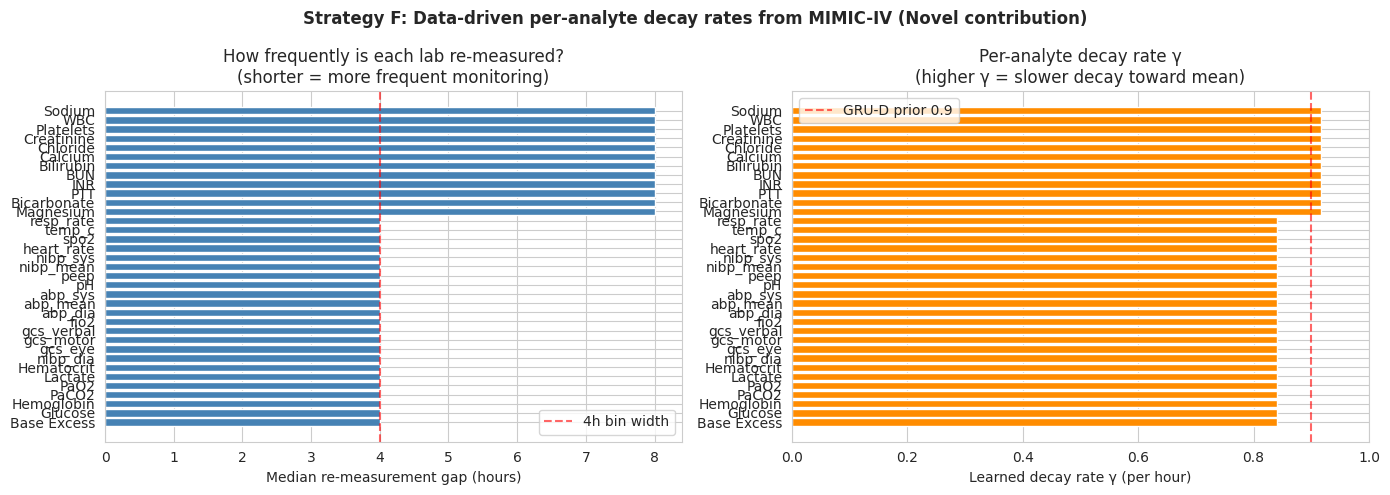

Saved: output/fig_strategy_F_decay_rates.png


In [10]:
# Visualise the decay rate table
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gdf = gamma_df.reset_index().sort_values("median_gap_h")

# Left: median re-measurement gap
axes[0].barh(gdf["analyte"], gdf["median_gap_h"], color="steelblue", edgecolor="white")
axes[0].set_xlabel("Median re-measurement gap (hours)")
axes[0].set_title("How frequently is each lab re-measured?\n(shorter = more frequent monitoring)")
axes[0].axvline(x=BIN_HOURS, color="red", linestyle="--", alpha=0.6, label="4h bin width")
axes[0].legend()

# Right: learned gamma
axes[1].barh(gdf["analyte"], gdf["gamma_per_h"], color="darkorange", edgecolor="white")
axes[1].set_xlabel("Learned decay rate γ (per hour)")
axes[1].set_title("Per-analyte decay rate γ\n(higher γ = slower decay toward mean)")
axes[1].axvline(x=0.9, color="red", linestyle="--", alpha=0.6, label="GRU-D prior 0.9")
axes[1].legend()
axes[1].set_xlim(0, 1)

plt.suptitle("Strategy F: Data-driven per-analyte decay rates from MIMIC-IV (Novel contribution)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT / "fig_strategy_F_decay_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/fig_strategy_F_decay_rates.png")

In [11]:
def apply_learned_decay(
    ts_df: pd.DataFrame,
    lab_cols: list,
    gamma_df: pd.DataFrame,
    bin_hours: int = BIN_HOURS,
) -> pd.DataFrame:
    """
    Forward fill then decay carried values toward empirical mean.

        x_imputed = gamma^delta_t * x_last + (1 - gamma^delta_t) * x_mean

    Bins before first measurement: imputed with global empirical mean directly.
    """
    ts = ts_df.sort_values(["stay_id", "bin_4h"]).copy()
    global_means = labs[lab_cols].mean()   # from original data to avoid leakage

    for lab in lab_cols:
        gamma  = gamma_df.loc[lab, "gamma_per_h"]
        x_mean = global_means[lab]

        # Last observed value (forward-filled)
        ts["_last_val"] = ts.groupby("stay_id")[lab].transform("ffill")

        # Hours since last measurement
        ts["_meas_bin"] = ts["bin_4h"].where(ts[lab].notna())
        ts["_lmb"]      = ts.groupby("stay_id")["_meas_bin"].transform("ffill")
        ts["_delta_t"]  = (ts["bin_4h"] - ts["_lmb"]) * bin_hours

        # Apply decay to gap bins (unmeasured, but a prior value exists)
        needs_decay = ts[lab].isna() & ts["_last_val"].notna()
        if needs_decay.any():
            decay_factor = gamma ** ts.loc[needs_decay, "_delta_t"]
            ts.loc[needs_decay, lab] = (
                decay_factor * ts.loc[needs_decay, "_last_val"]
                + (1 - decay_factor) * x_mean
            )

        # Bins before first measurement (no prior value): impute global mean
        ts[lab] = ts[lab].fillna(x_mean)

    ts = ts.drop(columns=["_last_val", "_meas_bin", "_lmb", "_delta_t"])
    return ts


print("Strategy F: Forward fill + learned per-analyte decay toward empirical mean")

# Step 1: recency features (computed on original data before any imputation)
ts_F = add_recency_features(labs, LAB_COLS)

# Step 2: apply learned decay imputation
ts_F = apply_learned_decay(ts_F, LAB_COLS, gamma_df, bin_hours=BIN_HOURS)

# Step 3: flatten + recency at last bin
flat_F = flatten_stays(ts_F, LAB_COLS, IND_COLS, extra_cols=RECENCY_COLS)

n_nan = flat_F[LAB_FEAT_COLS].isnull().sum().sum()
print(f"Shape   : {flat_F.shape}")
print(f"NaN in lab features: {n_nan}  (should be 0)")
assert n_nan == 0

Strategy F: Forward fill + learned per-analyte decay toward empirical mean
Shape   : (54551, 211)
NaN in lab features: 0  (should be 0)


---
## 11. Strategy G — Clinical-Default Imputation

**Clinical rationale:** When a clinician does not order a test in 24h, this is itself a clinical judgment: the patient is likely *stable* on that dimension. Imputing population-normal reference values exploits this inference — it is more clinically appropriate than borrowing from similar patients (KNN) or regressing from other labs (MICE), which may over-estimate abnormality.  
Sim et al. (2025) found normal-value imputation achieved AUROC 0.918 vs mean's 0.883 vs MICE's 0.827 for an AI early-warning score.  
Sharafoddini et al. (2019) reported 83.3% of lactate measurements were missing in stable patients — supporting the "not measured = normal" heuristic for stable-trajectory labs.

**Implementation:**  
1. Forward fill within each patient (handles gaps *between* measurements — value stays recent)  
2. Fill remaining NaN with population-normal reference value (before first measurement, or never ordered)

Reference values are sourced from standard adult laboratory reference ranges.

In [12]:
CLINICAL_DEFAULTS = {
    # ── Labs (20) ─────────────────────────────────────────────────────────────
    "BUN":         15.0,   # mg/dL          normal BUN
    "Base Excess":  0.0,   # mEq/L          zero = perfect acid-base balance
    "Bicarbonate": 24.0,   # mEq/L          normal serum HCO3
    "Bilirubin":    0.8,   # mg/dL          normal total bilirubin
    "Calcium":      9.0,   # mg/dL          normal total serum calcium
    "Chloride":   102.0,   # mEq/L          normal serum chloride
    "Creatinine":   0.9,   # mg/dL          sex-averaged normal creatinine
    "Glucose":    100.0,   # mg/dL          fasting normal glucose
    "Hematocrit":  42.0,   # %              sex-averaged normal
    "Hemoglobin":  14.0,   # g/dL           sex-averaged normal
    "INR":          1.1,   # ratio          normal INR (not anticoagulated)
    "Lactate":      1.0,   # mmol/L         Sim et al. (2025); Sharafoddini (2019)
    "Magnesium":    2.0,   # mg/dL          normal serum magnesium
    "PTT":         30.0,   # seconds        normal PTT
    "PaCO2":       40.0,   # mmHg           normal arterial CO2
    "PaO2":        95.0,   # mmHg           normal arterial O2 (room air)
    "Platelets":  250.0,   # x10^3/µL       normal platelet count
    "Sodium":     140.0,   # mEq/L          normal serum sodium
    "WBC":          7.5,   # x10^3/µL       normal WBC
    "pH":           7.40,  # arterial       normal arterial pH
    # ── Vitals (15) ───────────────────────────────────────────────────────────
    # Clinical reasoning: absent vital = patient not being continuously monitored
    # at high acuity → assume near-normal values (Sharafoddini et al., 2019)
    "heart_rate":  75.0,   # bpm            resting normal HR
    "abp_sys":    120.0,   # mmHg           normal arterial systolic
    "abp_dia":     80.0,   # mmHg           normal arterial diastolic
    "abp_mean":    93.0,   # mmHg           (SBP + 2xDBP)/3 ≈ 93 for 120/80
    "nibp_sys":   120.0,   # mmHg
    "nibp_dia":    80.0,   # mmHg
    "nibp_mean":   93.0,   # mmHg
    "resp_rate":   14.0,   # breaths/min    normal resting RR
    "spo2":        98.0,   # %              normal O2 saturation (room air)
    "temp_c":      37.0,   # °C             normal body temperature
    # Ventilator-only: absent = not intubated = impute room-air/no-PEEP values
    "fio2":        21.0,   # %              room air (not on supplemental O2)
    "peep":         0.0,   # cmH2O          no PEEP (not ventilated)
    "gcs_eye":      4.0,   # GCS-E          spontaneous eye opening = normal
    "gcs_verbal":   5.0,   # GCS-V          oriented = normal
    "gcs_motor":    6.0,   # GCS-M          obeys commands = normal
}

missing_defaults = [col for col in LAB_COLS if col not in CLINICAL_DEFAULTS]
assert not missing_defaults, f"No clinical default defined for: {missing_defaults}"
print(f"Clinical reference values defined for all {len(CLINICAL_DEFAULTS)} features:")
for feat, val in CLINICAL_DEFAULTS.items():
    print(f"  {feat:<18} {val}")

Clinical reference values defined for all 35 features:
  BUN                15.0
  Base Excess        0.0
  Bicarbonate        24.0
  Bilirubin          0.8
  Calcium            9.0
  Chloride           102.0
  Creatinine         0.9
  Glucose            100.0
  Hematocrit         42.0
  Hemoglobin         14.0
  INR                1.1
  Lactate            1.0
  Magnesium          2.0
  PTT                30.0
  PaCO2              40.0
  PaO2               95.0
  Platelets          250.0
  Sodium             140.0
  WBC                7.5
  pH                 7.4
  heart_rate         75.0
  abp_sys            120.0
  abp_dia            80.0
  abp_mean           93.0
  nibp_sys           120.0
  nibp_dia           80.0
  nibp_mean          93.0
  resp_rate          14.0
  spo2               98.0
  temp_c             37.0
  fio2               21.0
  peep               0.0
  gcs_eye            4.0
  gcs_verbal         5.0
  gcs_motor          6.0


In [13]:
print("Strategy G: Clinical-default imputation")

ts_G = labs.sort_values(["stay_id", "bin_4h"]).copy()

# Step 1: forward fill within each stay (gaps between measurements)
ts_G[LAB_COLS] = ts_G.groupby("stay_id")[LAB_COLS].transform("ffill")

# Step 2: remaining NaN = before first measurement OR lab never ordered
#         fill with clinical reference value
for lab in LAB_COLS:
    ts_G[lab] = ts_G[lab].fillna(CLINICAL_DEFAULTS[lab])

flat_G = flatten_stays(ts_G, LAB_COLS, IND_COLS)

n_nan = flat_G[LAB_FEAT_COLS].isnull().sum().sum()
print(f"Shape   : {flat_G.shape}")
print(f"NaN in lab features: {n_nan}  (should be 0)")
assert n_nan == 0

Strategy G: Clinical-default imputation
Shape   : (54551, 176)
NaN in lab features: 0  (should be 0)


---
## 12. Strategy D — KNN (k = 5)

**Clinical rationale:** Borrows information from the 5 most similar patients in the cohort to estimate missing lab values. Partially addresses MNAR: if similar-severity patient A had lactate measured, patient B's missing lactate can be estimated from A's value.  
Applied **cross-sectionally** to the already-flattened patient matrix (Strategy A flat) — each patient is represented by their 80 lab aggregate features (`mean/min/max/last`), and KNN finds the nearest neighbours in this space.  
Sensitivity analysis: k=3, 5, 11 (standard choices in clinical imputation literature; NIMI-research benchmark).  
Euclidean distance; uniform weighting.

In [ ]:
import time

print("Strategy D: KNN imputation (k=5, cross-sectional on flattened matrix)")
print(f"Input: flat_A  shape={flat_A.shape}")
print(f"KNN operates on {len(LAB_FEAT_COLS)} lab feature columns")
print("Note: sklearn KNNImputer uses brute-force O(n²) distances — expect 20-40 min on full cohort.")

t0 = time.time()
knn = KNNImputer(n_neighbors=5, weights="uniform")
arr_knn = knn.fit_transform(flat_A[LAB_FEAT_COLS])

flat_D = flat_A.copy()
flat_D[LAB_FEAT_COLS] = arr_knn

print(f"KNN completed in {(time.time()-t0)/60:.1f} minutes")
print(f"Shape   : {flat_D.shape}")
print(f"NaN in lab features: {flat_D[LAB_FEAT_COLS].isnull().sum().sum()}  (should be 0)")
assert flat_D[LAB_FEAT_COLS].isnull().sum().sum() == 0

Strategy D: KNN imputation (k=5, cross-sectional on flattened matrix)
Input: flat_A  shape=(54551, 176)
KNN operates on 140 lab feature columns
Note: sklearn KNNImputer uses brute-force O(n²) distances — expect 20-40 min on full cohort.
KNN completed in 24.7 minutes
Shape   : (54551, 176)
NaN in lab features: 0  (should be 0)
  k=3    mean absolute difference from k=5: 1.1789


---
## 13. Strategy E — MICE / IterativeImputer (LightGBM estimator)

**Clinical rationale:** Multiple Imputation by Chained Equations (MICE) models each lab feature as a function of all others using a flexible non-linear estimator. ICU labs are highly correlated (e.g., creatinine and BUN both reflect renal function; pH, PaCO2, and bicarbonate reflect acid-base balance), so MICE can exploit these relationships to produce more accurate imputations than single-variable methods.  
**Caveat:** MICE assumes MAR, not MNAR — estimates may be biased when missingness is informative. We partially mitigate this by including `was_measured_*` indicators as covariates (they encode the missingness mechanism exogenously).  
Applied cross-sectionally on the flattened matrix (Strategy A flat). LightGBM estimator handles non-linear relationships and interactions between labs without manual feature engineering.

> **Note:** This cell may take 10–20 minutes to run (32 iterations × 80 features × 54 551 patients). LightGBM parallelises internally (`n_jobs=-1`).

In [15]:
import time

print("Strategy E: MICE (IterativeImputer + LightGBM, max_iter=32)")
print(f"Input: flat_A  shape={flat_A.shape}")
print(f"Operating on {len(LAB_FEAT_COLS)} lab feature columns (+ was_measured_* as conditioning)\n")

# We include was_measured_* columns as additional regressors inside MICE
# so the imputer can condition on missingness indicators — partial MNAR mitigation
mice_input_cols = LAB_FEAT_COLS + IND_COLS

estimator_mice = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    n_jobs=-1,
    random_state=SEED,
    verbosity=-1,
)

mice = IterativeImputer(
    estimator=estimator_mice,
    max_iter=32,
    random_state=SEED,
    initial_strategy="median",
    n_nearest_features=20,   # limit each var to 20 most correlated predictors: 3-5x faster
    verbose=0,
)

t0 = time.time()
arr_mice = mice.fit_transform(flat_A[mice_input_cols])
elapsed = time.time() - t0
print(f"MICE completed in {elapsed/60:.1f} minutes")

# arr_mice columns correspond to mice_input_cols; extract only lab feature columns
flat_E = flat_A.copy()
flat_E[mice_input_cols] = arr_mice

n_nan = flat_E[LAB_FEAT_COLS].isnull().sum().sum()
print(f"Shape   : {flat_E.shape}")
print(f"NaN in lab features: {n_nan}  (should be 0)")
assert n_nan == 0

Strategy E: MICE (IterativeImputer + LightGBM, max_iter=32)
Input: flat_A  shape=(54551, 176)
Operating on 140 lab feature columns (+ was_measured_* as conditioning)

MICE completed in 26.3 minutes
Shape   : (54551, 176)
NaN in lab features: 0  (should be 0)


---
## 14. Add Demographics + Save All 7 Parquets

In [16]:
def add_demographics(flat_df: pd.DataFrame, cohort_df: pd.DataFrame) -> pd.DataFrame:
    """Merge age and binary gender (F=0, M=1) from cohort."""
    demo = cohort_df[["stay_id", "age", "gender"]].copy()
    demo["gender_binary"] = (demo["gender"] == "M").astype(int)
    demo = demo.drop(columns=["gender"])
    return flat_df.merge(demo, on="stay_id", how="left")


strategies = {
    "native_nan":       flat_A,
    "median":           flat_B,
    "ffill_recency":    flat_C,
    "ffill_decay":      flat_F,
    "clinical_default": flat_G,
    "knn":              flat_D,
    "mice":             flat_E,
}

print("Adding demographics (age, gender_binary) and saving parquets...\n")
for key, flat in strategies.items():
    out = add_demographics(flat, cohort)
    path = OUTPUT / f"imputed_{key}.parquet"
    out.to_parquet(path, index=False)
    n_nan = out.drop(columns=["stay_id"]).isnull().sum().sum()
    print(f"  {key:<22}  shape={out.shape}  NaN={n_nan:,}  -> {path}")

print("\nDone.")

Adding demographics (age, gender_binary) and saving parquets...

  native_nan              shape=(54551, 178)  NaN=2,174,528  -> output/imputed_native_nan.parquet
  median                  shape=(54551, 178)  NaN=0  -> output/imputed_median.parquet
  ffill_recency           shape=(54551, 213)  NaN=0  -> output/imputed_ffill_recency.parquet
  ffill_decay             shape=(54551, 213)  NaN=0  -> output/imputed_ffill_decay.parquet
  clinical_default        shape=(54551, 178)  NaN=0  -> output/imputed_clinical_default.parquet
  knn                     shape=(54551, 178)  NaN=0  -> output/imputed_knn.parquet
  mice                    shape=(54551, 178)  NaN=0  -> output/imputed_mice.parquet

Done.


---
## 15. Verification

In [17]:
print("=== Verification: saved Parquet files ===\n")

rows = []
for key in strategies:
    df = pd.read_parquet(OUTPUT / f"imputed_{key}.parquet")
    non_id = [c for c in df.columns if c != "stay_id"]
    n_nan  = df[non_id].isnull().sum().sum()
    n_rows = df.shape[0]
    n_cols = df.shape[1]
    rows.append({
        "strategy":    key,
        "rows":        n_rows,
        "columns":     n_cols,
        "NaN_total":   n_nan,
        "NaN_allowed": key == "native_nan",
    })

summary = pd.DataFrame(rows).set_index("strategy")
print(summary.to_string())

# Assertions
for _, row in summary.iterrows():
    if not row["NaN_allowed"]:
        assert row["NaN_total"] == 0, f"{row.name}: unexpected NaN ({row['NaN_total']})"
    assert row["rows"] == cohort.shape[0], f"{row.name}: row count mismatch"

print("\nAll assertions passed:")
print("  - All strategies except native_nan: zero NaN  ✓")
print("  - All strategies: 54 551 rows (one per stay)  ✓")
print("  - native_nan: NaN present (intentional, for LightGBM NaN-routing)  ✓")

=== Verification: saved Parquet files ===

                   rows  columns  NaN_total  NaN_allowed
strategy                                                
native_nan        54551      178    2174528         True
median            54551      178          0        False
ffill_recency     54551      213          0        False
ffill_decay       54551      213          0        False
clinical_default  54551      178          0        False
knn               54551      178          0        False
mice              54551      178          0        False

All assertions passed:
  - All strategies except native_nan: zero NaN  ✓
  - All strategies: 54 551 rows (one per stay)  ✓
  - native_nan: NaN present (intentional, for LightGBM NaN-routing)  ✓


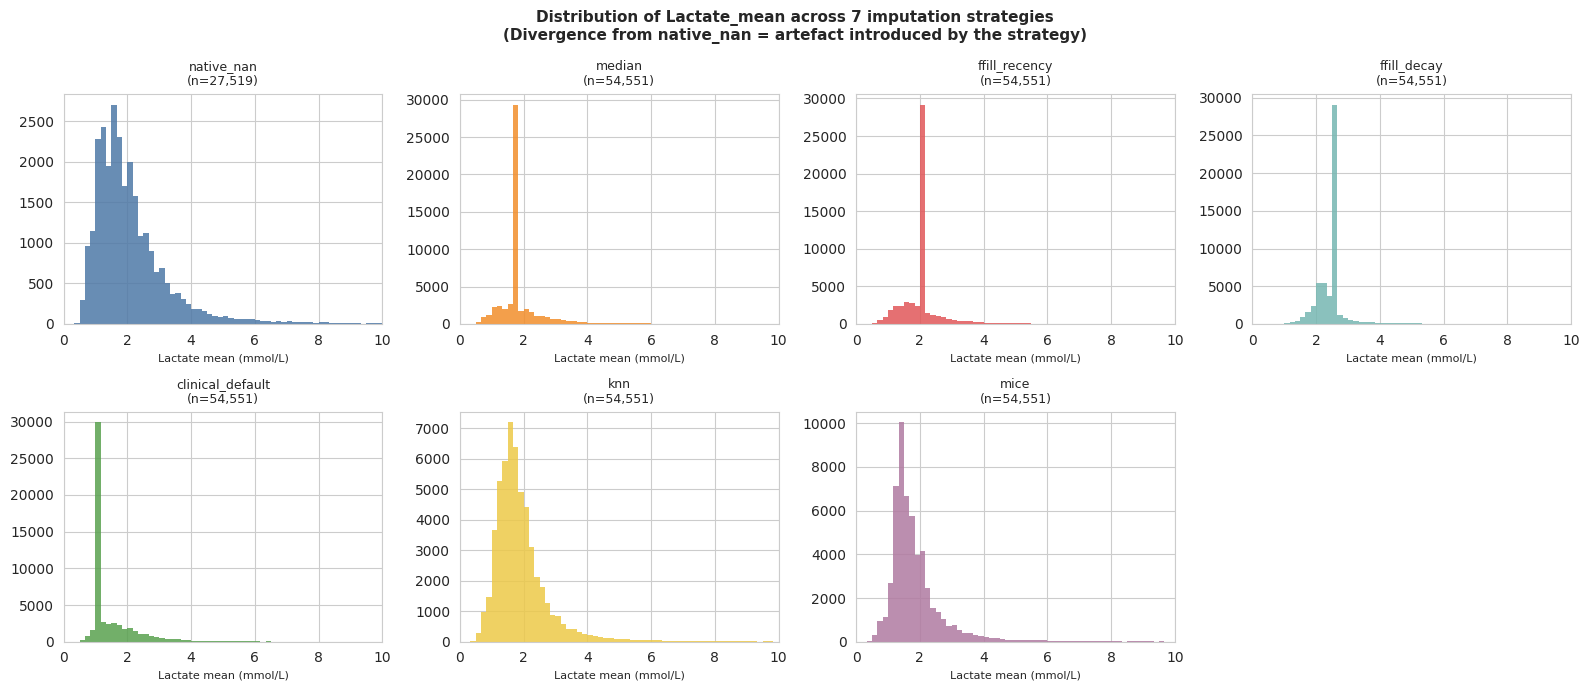

Saved: output/fig_lactate_distribution_comparison.png


In [18]:
# Quick distribution comparison: Lactate imputed values across strategies
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

strat_colors = {
    "native_nan":       "#4e79a7",
    "median":           "#f28e2b",
    "ffill_recency":    "#e15759",
    "ffill_decay":      "#76b7b2",
    "clinical_default": "#59a14f",
    "knn":              "#edc948",
    "mice":             "#b07aa1",
}

for ax, (key, color) in zip(axes, strat_colors.items()):
    df = pd.read_parquet(OUTPUT / f"imputed_{key}.parquet")
    vals = df["Lactate_mean"].dropna()
    ax.hist(vals, bins=60, color=color, edgecolor="none", alpha=0.85,
            range=(0, 10))  # clip display to 0–10 mmol/L
    ax.set_title(f"{key}\n(n={len(vals):,})", fontsize=9)
    ax.set_xlabel("Lactate mean (mmol/L)", fontsize=8)
    ax.set_xlim(0, 10)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("Distribution of Lactate_mean across 7 imputation strategies\n"
             "(Divergence from native_nan = artefact introduced by the strategy)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT / "fig_lactate_distribution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/fig_lactate_distribution_comparison.png")

---
## Summary

| File | Strategy | Temporal | NaN | Extra features |
|------|----------|----------|-----|----------------|
| `imputed_native_nan.parquet` | A — No imputation | — | Yes (intentional) | — |
| `imputed_median.parquet` | B — Global median | before flatten | No | — |
| `imputed_ffill_recency.parquet` | C — ffill + recency | before flatten | No | `recency_<lab>` (20 cols) |
| `imputed_ffill_decay.parquet` | F — ffill + learned decay | before flatten | No | `recency_<lab>` (20 cols) |
| `imputed_clinical_default.parquet` | G — clinical defaults | before flatten | No | — |
| `imputed_knn.parquet` | D — KNN (k=5) | cross-sectional | No | — |
| `imputed_mice.parquet` | E — MICE + LightGBM | cross-sectional | No | — |

All 7 files contain `stay_id`, 80 lab features (`{lab}_{mean/min/max/last}`), 20 `was_measured_*` indicators, `age`, and `gender_binary`.

**Next step → `04_evaluate.ipynb`:** Load all 7 Parquets, run identical LightGBM 5-fold CV on each, compare AUROC/AUPRC/Brier score.